In [29]:
from dotenv import load_dotenv
load_dotenv()

from langgraph.graph import StateGraph,START,END
from typing import TypedDict

from langchain_mistralai import ChatMistralAI

from langchain_core.messages import AnyMessage,AIMessage

from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver

from langgraph.types import interrupt,Command
from langchain_core.messages import BaseMessage

from typing import Annotated 





In [30]:
llm = ChatMistralAI(
    model = "mistral-small-latest"
)

In [31]:
llm.invoke("Hello")

AIMessage(content='Hello! How can I assist you today? 😊', additional_kwargs={}, response_metadata={'token_usage': {'prompt_tokens': 16, 'total_tokens': 29, 'completion_tokens': 13, 'prompt_tokens_details': {'cached_tokens': 0}}, 'model_name': 'mistral-small-latest', 'model': 'mistral-small-latest', 'finish_reason': 'stop', 'model_provider': 'mistralai'}, id='lc_run--019d0105-3779-7db1-9800-40f5d66ec5ef-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 16, 'output_tokens': 13, 'total_tokens': 29})

In [32]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage],add_messages]

    

In [33]:
def chat_node(state: ChatState):
    decision = interrupt(
        {
            "type": "approval",
            "reason": "Model is about to answer a user question.",
            "questions": state["messsages"][-1].content,
            "instuctions": "Approve this question? yes/no"
        }
    )
    if decision["approved"] == "no":
        return {
            "messages": [AIMessage(content="Not approved.")]
        }
    else:
        response = llm.invoke(state["messsages"])
        return {
            "messages": [response]
        }


In [34]:
# define the graph with state 
builder = StateGraph(state_schema=ChatState)

In [35]:
#add nodes to the graph 
builder.add_node(
    "chat",
    chat_node
)

In [36]:
# add edges to the graph 
builder.add_edge(START,"chat")
builder.add_edge("chat",END)


In [37]:
checkpointer = MemorySaver()

In [38]:
# compile the graph 
workflow = builder.compile(checkpointer=MemorySaver())


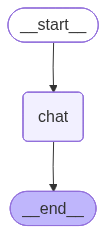

In [39]:
workflow

In [40]:
config={
    "configurable": {
        "thread_id": "1234"
    }
}

In [41]:
from langchain_core.messages import HumanMessage

In [42]:
# making initial state for triggering the workflow 
initial_state = {
    "messages": [
        HumanMessage(content="Explain about LangChain CLI")
    ],
}


In [43]:
#execute the graph 
final_state = workflow.invoke(initial_state,config = config)

KeyError: 'messsages'

In [ ]:
final_state

{'title': 'Indian Ocean',
 'outline': '### **Blog Outline: The Indian Ocean – A Gateway to History, Trade, and Biodiversity**\n\n#### **Title:** *The Indian Ocean: A Vast Maritime Realm of Trade, Culture, and Life*\n\n#### **Introduction**\n- Hook: *"Stretching from the east coast of Africa to the shores of Australia, the Indian Ocean is the third-largest ocean in the world—but its significance goes far beyond its size."*\n- Brief overview of the Indian Ocean’s geographical importance.\n- Why studying the Indian Ocean matters: trade routes, cultural exchanges, biodiversity, and geopolitical influence.\n- Thesis statement: *The Indian Ocean has shaped civilizations, economies, and ecosystems for millennia, making it one of the most dynamic maritime regions in history.*\n\n---\n\n### **I. Geography & Oceanography of the Indian Ocean**\n1. **Size & Location**\n   - Third-largest ocean (70.56 million km²).\n   - Bounded by Africa (west), Asia (north), Australia (east), and the Southern Oce

In [ ]:
print(final_state["outline"])

### **Blog Outline: The Indian Ocean – A Gateway to History, Trade, and Biodiversity**

#### **Title:** *The Indian Ocean: A Vast Maritime Realm of Trade, Culture, and Life*

#### **Introduction**
- Hook: *"Stretching from the east coast of Africa to the shores of Australia, the Indian Ocean is the third-largest ocean in the world—but its significance goes far beyond its size."*
- Brief overview of the Indian Ocean’s geographical importance.
- Why studying the Indian Ocean matters: trade routes, cultural exchanges, biodiversity, and geopolitical influence.
- Thesis statement: *The Indian Ocean has shaped civilizations, economies, and ecosystems for millennia, making it one of the most dynamic maritime regions in history.*

---

### **I. Geography & Oceanography of the Indian Ocean**
1. **Size & Location**
   - Third-largest ocean (70.56 million km²).
   - Bounded by Africa (west), Asia (north), Australia (east), and the Southern Ocean (south).
   - Key subregions: Arabian Sea, Bay of B

In [ ]:
print(final_state['blog'])

# **The Indian Ocean: A Vast Maritime Realm of Trade, Culture, and Life**

### *By [Your Name]*

---

## **Introduction**

*"Stretching from the east coast of Africa to the shores of Australia, the Indian Ocean is the third-largest ocean in the world—but its significance goes far beyond its size."*

For millennia, this vast expanse of blue has been more than just water—it has been a highway of civilizations, a battleground for empires, a cradle of biodiversity, and a stage for geopolitical maneuvering. Home to over **2,000 species of fish**, some of the world’s most critical trade routes, and the remnants of ancient maritime cultures, the Indian Ocean remains one of the most dynamic and strategically vital regions on Earth.

From the **spice trade that connected Rome to Indonesia** to the modern-day **China-led "String of Pearls" strategy**, the Indian Ocean has shaped economies, religions, and ecosystems for thousands of years. Yet, today, it faces unprecedented threats—**climate chan